# 🏦 Customer Churn Analysis and Predictive Reporting
### Using Machine Learning and Power BI
**Symbiosis Skills & Professional University — B.Sc Data Science**

---

### 📋 Project Flow:
1. Connect to MySQL & Load Data
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Encode & Scale Features
5. Handle Class Imbalance (SMOTE)
6. Train Multiple ML Models
7. Compare & Evaluate Models
8. Feature Importance
9. Save Best Model

## Step 1: Import All Required Libraries

In [69]:
# ── Basic libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # suppress unnecessary warnings

# ── Visualization ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── MySQL connection ──────────────────────────────────────────────
import mysql.connector

# ── Preprocessing ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Handle class imbalance ────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Machine Learning Models ───────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Model Evaluation ──────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ── Save the trained model ────────────────────────────────────────
import joblib

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Connect to MySQL & Load Data
> Instead of reading directly from CSV, we fetch the customer data from our MySQL database. This covers the **RDBMS subject** of our project.

In [72]:
# ── Connect to MySQL database ──────────────────────────────────────
# Make sure MySQL is running and churn_db database exists
connection = mysql.connector.connect(
    host='localhost',
    user='root',           # change to your MySQL username
    password='elsa123$',  # change to your MySQL password
    database='churn_db'
)

# ── Fetch all customer records from the database ───────────────────
df_mysql = pd.read_sql('SELECT * FROM customers', connection)
df = df_mysql.copy()

# ── Close the connection once data is loaded ───────────────────────
connection.close()

print('✅ Data fetched from MySQL successfully!')
print(f'   Total records : {df.shape[0]}')
print(f'   Total columns : {df.shape[1]}')
print()
print('First 5 rows:')
df.head()

✅ Data fetched from MySQL successfully!
   Total records : 10000
   Total columns : 15

First 5 rows:


,id,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Data Cleaning

In [75]:
# ── Drop columns that are NOT useful for prediction ────────────────
# RowNumber, CustomerId, Surname are just identifiers — not features
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print('✅ Dropped: RowNumber, CustomerId, Surname')

# ── Check for missing values ───────────────────────────────────────
print('\n🔍 Missing values per column:')
print(df.isnull().sum())

# ── Check for duplicate rows ───────────────────────────────────────
print(f'\n🔍 Duplicate rows: {df.duplicated().sum()}')

# ── Basic info about the dataset ───────────────────────────────────
print('\n📊 Dataset Info:')
print(df.info())

# ── Statistical summary ────────────────────────────────────────────
print('\n📊 Statistical Summary:')
df.describe()

✅ Dropped: RowNumber, CustomerId, Surname

🔍 Missing values per column:
id                 0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

🔍 Duplicate rows: 0

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               10000 non-null  int64  
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  object 
 3   Gender           10000 non-null  object 
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActi

,id,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Step 4: Exploratory Data Analysis (EDA)
> We explore the data visually to understand patterns, distributions, and relationships with churn.

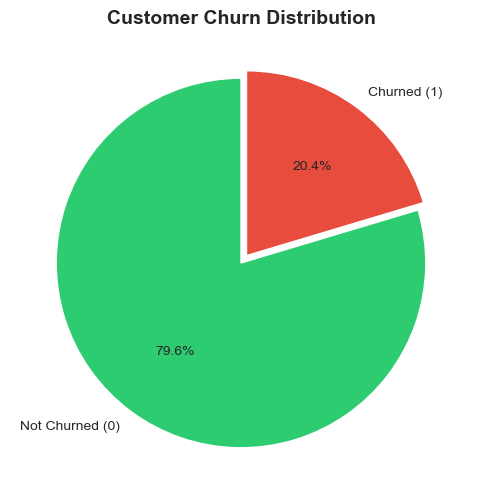

💡 Insight: Dataset is imbalanced — only ~20% customers churned


In [78]:
# ── Set a consistent style for all plots ──────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
colors = ['#2ecc71', '#e74c3c']  # green = stayed, red = churned

# ── Plot 1: Churn Distribution (Pie Chart) ────────────────────────
churn_counts = df['Exited'].value_counts()
labels = ['Not Churned (0)', 'Churned (1)']

plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.savefig('churn_distribution.png', bbox_inches='tight')  # save for Power BI
plt.show()
print('💡 Insight: Dataset is imbalanced — only ~20% customers churned')

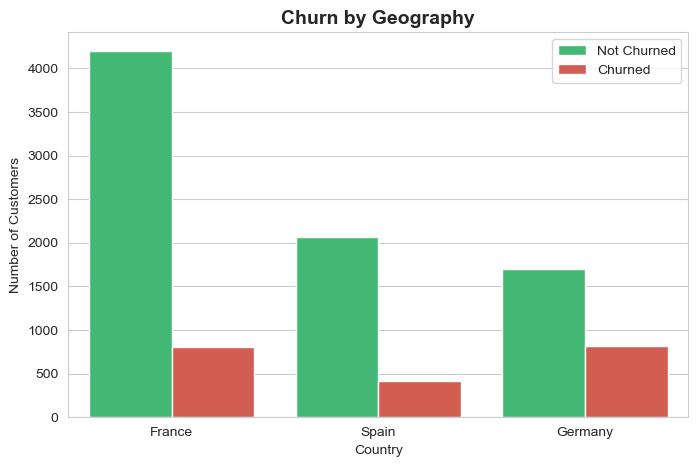

💡 Insight: Germany has a noticeably higher churn rate compared to France and Spain


In [80]:
# ── Plot 2: Churn by Geography ────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Geography',
    hue='Exited',
    palette={0: '#2ecc71', 1: '#e74c3c'}
)
plt.title('Churn by Geography', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.legend(labels=['Not Churned', 'Churned'])
plt.savefig('churn_by_geography.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Germany has a noticeably higher churn rate compared to France and Spain')

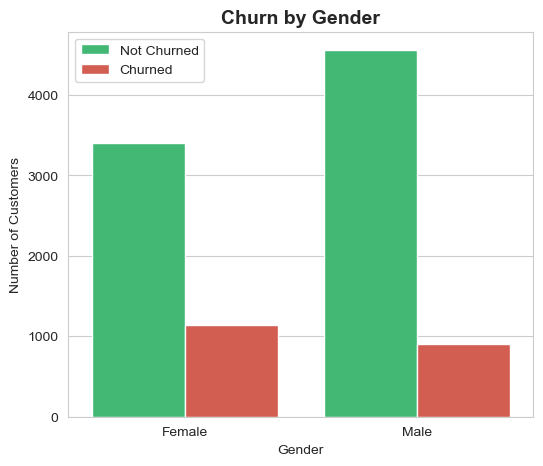

💡 Insight: Female customers churn more than male customers


In [82]:
# ── Plot 3: Churn by Gender ───────────────────────────────────────
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df,
    x='Gender',
    hue='Exited',
    palette={0: '#2ecc71', 1: '#e74c3c'}
)
plt.title('Churn by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(labels=['Not Churned', 'Churned'])
plt.savefig('churn_by_gender.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Female customers churn more than male customers')

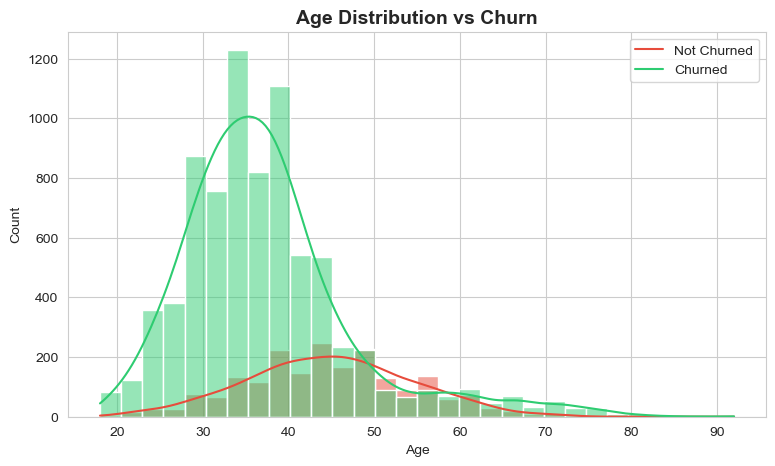

💡 Insight: Older customers (40-60) are more likely to churn


In [84]:
# ── Plot 4: Age Distribution vs Churn ────────────────────────────
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Age',
    hue='Exited',
    bins=30,
    kde=True,
    palette={0: '#2ecc71', 1: '#e74c3c'}
)
plt.title('Age Distribution vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Not Churned', 'Churned'])
plt.savefig('age_vs_churn.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Older customers (40-60) are more likely to churn')

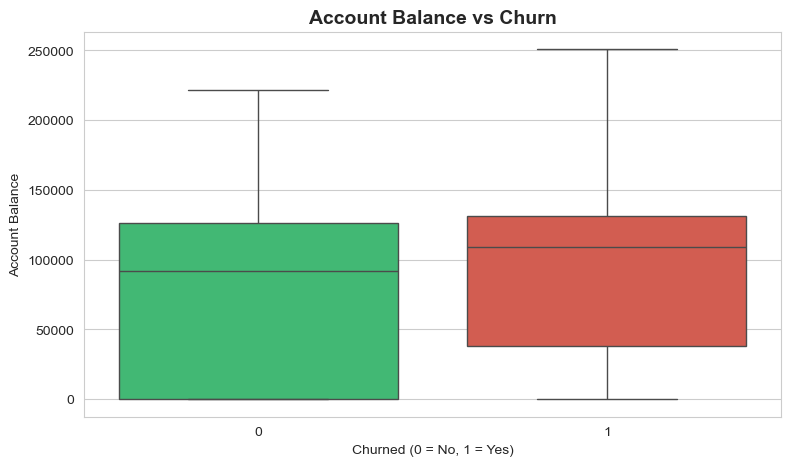

💡 Insight: Customers with higher balances tend to churn more


In [86]:
# ── Plot 5: Balance vs Churn ──────────────────────────────────────
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='Exited',
    y='Balance',
    palette={'0': '#2ecc71', '1': '#e74c3c'}
)
plt.title('Account Balance vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Account Balance')
plt.savefig('balance_vs_churn.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Customers with higher balances tend to churn more')

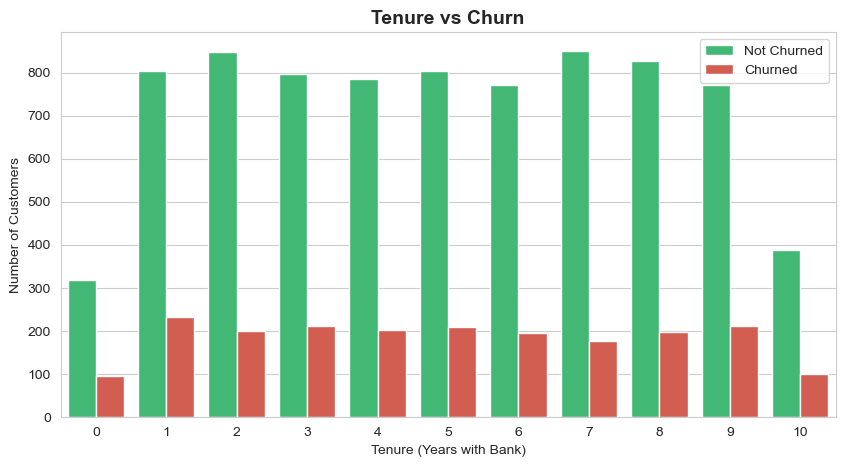

💡 Insight: Churn is fairly spread across all tenure groups


In [88]:
# ── Plot 6: Tenure vs Churn ───────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='Tenure',
    hue='Exited',
    palette={0: '#2ecc71', 1: '#e74c3c'}
)
plt.title('Tenure vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Years with Bank)')
plt.ylabel('Number of Customers')
plt.legend(labels=['Not Churned', 'Churned'])
plt.savefig('tenure_vs_churn.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Churn is fairly spread across all tenure groups')

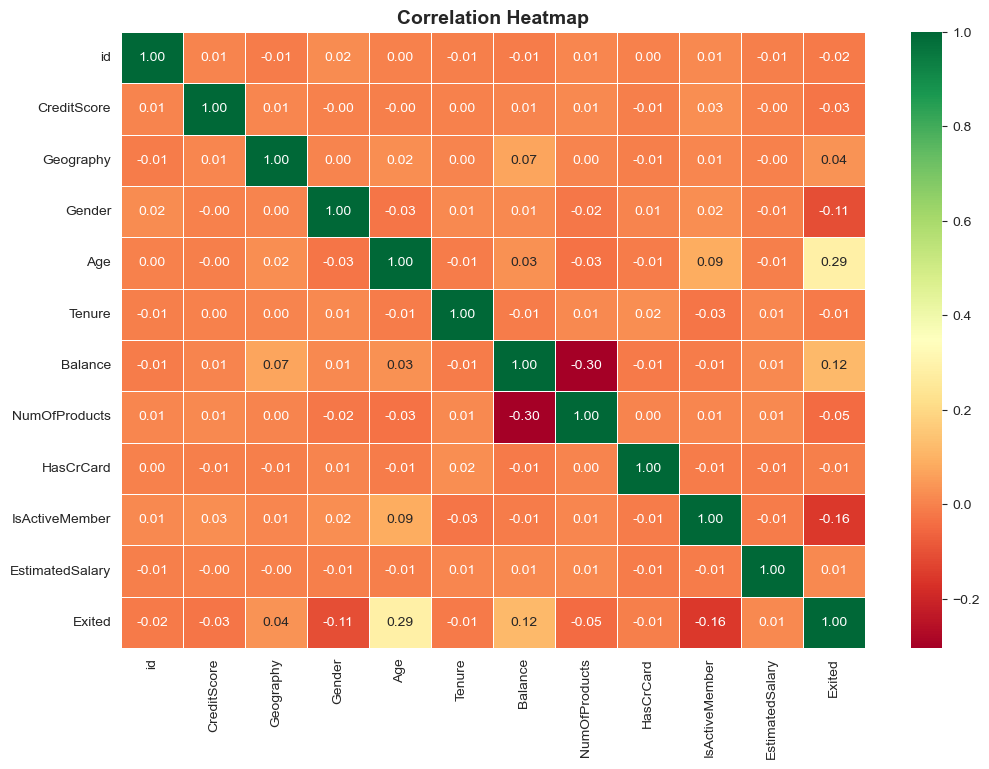

💡 Insight: Age and IsActiveMember have the strongest correlation with Exited


In [90]:
# ── Plot 7: Correlation Heatmap ───────────────────────────────────
# Encode categorical columns temporarily just for correlation
df_corr = df.copy()
df_corr['Gender'] = LabelEncoder().fit_transform(df_corr['Gender'])
df_corr['Geography'] = LabelEncoder().fit_transform(df_corr['Geography'])

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Age and IsActiveMember have the strongest correlation with Exited')

## Step 5: Encode Categorical Variables
> ML models only understand numbers, so we convert text columns (Gender, Geography) into numeric form.

In [93]:
# ── Label encode Gender column ─────────────────────────────────────
# Female = 0, Male = 1
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])
print('✅ Gender encoded: Female=0, Male=1')

# ── One-Hot encode Geography column ───────────────────────────────
# Creates separate columns: Geography_Germany, Geography_Spain
# France becomes the baseline (drop_first=True removes it)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
print('✅ Geography one-hot encoded')

print('\n📊 Updated dataset columns:')
print(df.columns.tolist())
df.head()

✅ Gender encoded: Female=0, Male=1
✅ Geography one-hot encoded

📊 Updated dataset columns:
['id', 'CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,id,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,4,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,5,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Step 6: Define Features and Target Variable

In [96]:
# ── X = input features (everything except the target) ─────────────
X = df.drop('Exited', axis=1)

# ── y = target variable (what we want to predict) ─────────────────
# 1 = Customer Churned, 0 = Customer Stayed
y = df['Exited']

print(f'✅ Features shape : {X.shape}')
print(f'✅ Target shape   : {y.shape}')
print(f'\n📊 Target distribution:')
print(y.value_counts())
print(f'\n⚠️  Class imbalance ratio: {round(y.value_counts()[0]/y.value_counts()[1], 2)}:1')

✅ Features shape : (10000, 12)
✅ Target shape   : (10000,)

📊 Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

⚠️  Class imbalance ratio: 3.91:1


## Step 7: Feature Scaling
> StandardScaler transforms all features to the same scale so no single feature dominates the model.

In [99]:
# ── Scale all features using StandardScaler ────────────────────────
# This converts all values to mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler — needed later for the website prediction
joblib.dump(scaler, 'scaler.pkl')

print('✅ Features scaled using StandardScaler')
print('✅ Scaler saved as scaler.pkl')

✅ Features scaled using StandardScaler
✅ Scaler saved as scaler.pkl


## Step 8: Handle Class Imbalance using SMOTE
> Our data has 79% non-churn and 21% churn — this imbalance makes the model biased.
> SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples for the minority class to balance it out.

In [102]:
# ── Apply SMOTE to balance the dataset ────────────────────────────
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print('✅ SMOTE applied successfully!')
print(f'\nBefore SMOTE:')
print(f'  Not Churned : {sum(y == 0)}')
print(f'  Churned     : {sum(y == 1)}')
print(f'\nAfter SMOTE:')
print(f'  Not Churned : {sum(y_balanced == 0)}')
print(f'  Churned     : {sum(y_balanced == 1)}')
print('\n💡 Now both classes are equal — model will be unbiased!')

✅ SMOTE applied successfully!

Before SMOTE:
  Not Churned : 7963
  Churned     : 2037

After SMOTE:
  Not Churned : 7963
  Churned     : 7963

💡 Now both classes are equal — model will be unbiased!


## Step 9: Train-Test Split
> We split the balanced data into 80% training and 20% testing.

In [105]:
# ── Split into training and testing sets ──────────────────────────
# test_size=0.2 means 20% data for testing, 80% for training
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42
)

print(f'✅ Data split complete!')
print(f'   Training samples : {X_train.shape[0]}')
print(f'   Testing samples  : {X_test.shape[0]}')

✅ Data split complete!
   Training samples : 12740
   Testing samples  : 3186


## Step 10: Train All 4 ML Models
> We train 4 different models and compare them to find the best one.

In [108]:
# ── Model 1: Logistic Regression ──────────────────────────────────
# Simple linear model — good baseline for binary classification
print('🔄 Training Logistic Regression...')
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
print(f'✅ Logistic Regression — Accuracy: {lr_acc:.4f} | AUC: {lr_auc:.4f}')

# ── Model 2: Decision Tree ────────────────────────────────────────
# Tree-based model — easy to interpret and visualize
print('\n🔄 Training Decision Tree...')
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
print(f'✅ Decision Tree — Accuracy: {dt_acc:.4f} | AUC: {dt_auc:.4f}')

# ── Model 3: Random Forest ────────────────────────────────────────
# Ensemble of many decision trees — generally very accurate
print('\n🔄 Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f'✅ Random Forest — Accuracy: {rf_acc:.4f} | AUC: {rf_auc:.4f}')

# ── Model 4: XGBoost ──────────────────────────────────────────────
# Gradient boosting — state-of-the-art for tabular data
print('\n🔄 Training XGBoost...')
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print(f'✅ XGBoost — Accuracy: {xgb_acc:.4f} | AUC: {xgb_auc:.4f}')

🔄 Training Logistic Regression...
✅ Logistic Regression — Accuracy: 0.7134 | AUC: 0.7727

🔄 Training Decision Tree...
✅ Decision Tree — Accuracy: 0.8220 | AUC: 0.8927

🔄 Training Random Forest...
✅ Random Forest — Accuracy: 0.8936 | AUC: 0.9626

🔄 Training XGBoost...
✅ XGBoost — Accuracy: 0.8992 | AUC: 0.9598


## Step 11: Compare All Models

📊 Model Comparison Table:
              Model  Accuracy  AUC Score
            XGBoost    0.8992     0.9598
      Random Forest    0.8936     0.9626
      Decision Tree    0.8220     0.8927
Logistic Regression    0.7134     0.7727


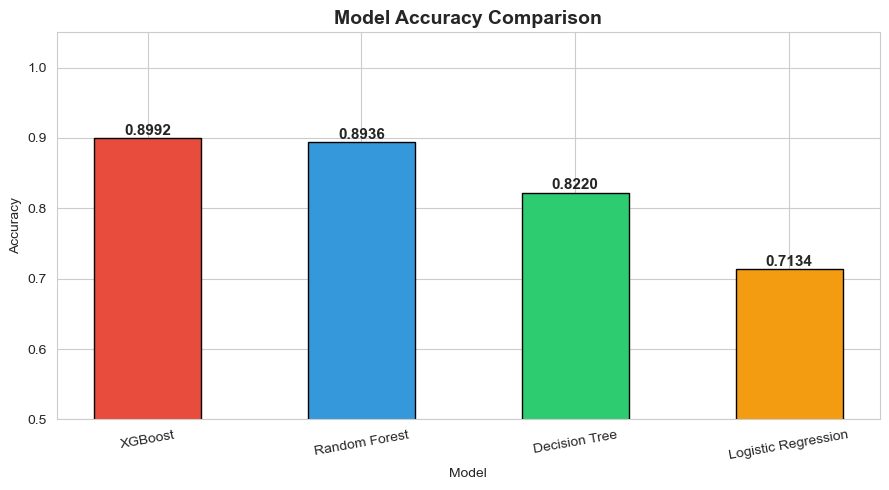

In [111]:
# ── Create a comparison table ──────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, dt_acc, rf_acc, xgb_acc],
    'AUC Score': [lr_auc, dt_auc, rf_auc, xgb_auc]
})

# Round to 4 decimal places for clean display
results['Accuracy'] = results['Accuracy'].round(4)
results['AUC Score'] = results['AUC Score'].round(4)

# Sort by accuracy descending
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('📊 Model Comparison Table:')
print(results.to_string(index=False))

# ── Plot accuracy comparison bar chart ────────────────────────────
plt.figure(figsize=(9, 5))
bars = plt.bar(
    results['Model'],
    results['Accuracy'],
    color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'],
    edgecolor='black',
    width=0.5
)

# Add accuracy value labels on top of each bar
for bar, val in zip(bars, results['Accuracy']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## Grouped Bar Chart

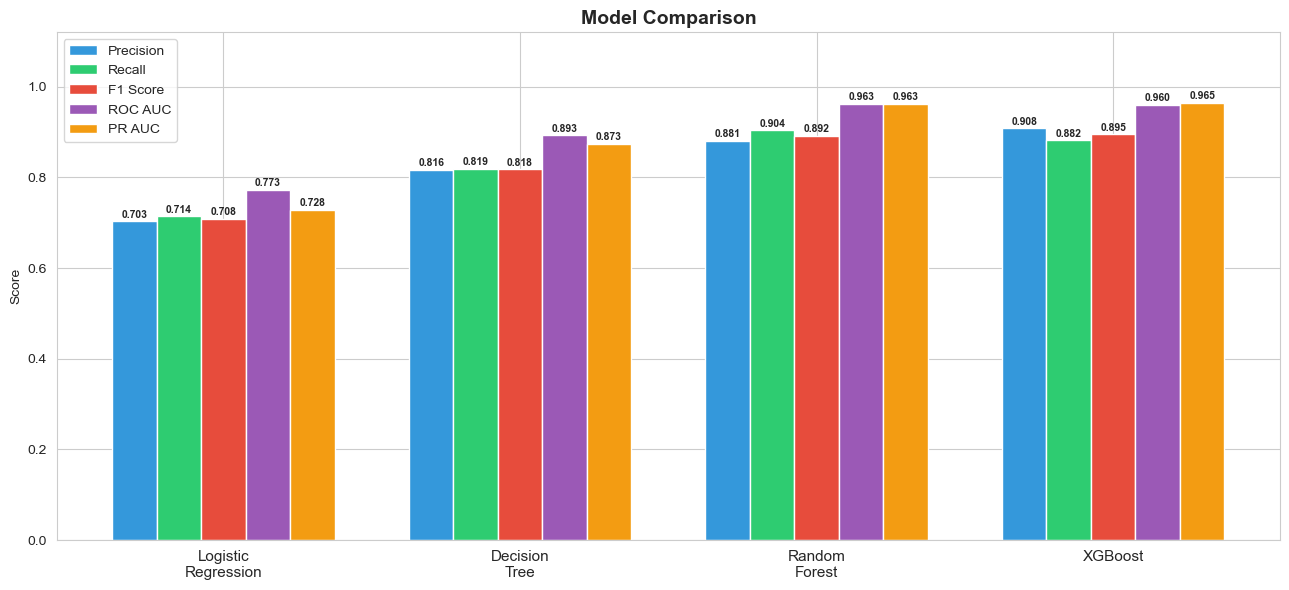

💡 Insight: Random Forest and XGBoost outperform Logistic Regression across all metrics!


In [114]:
# ── Plot: Model Comparison — Multi Metric Grouped Bar Chart ───────
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# ── Calculate metrics for all 4 models ────────────────────────────
model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost']
preds       = [lr_pred, dt_pred, rf_pred, xgb_pred]
models_list = [lr_model, dt_model, rf_model, xgb_model]

precision_scores = [precision_score(y_test, p)                              for p in preds]
recall_scores    = [recall_score(y_test, p)                                 for p in preds]
f1_scores        = [f1_score(y_test, p)                                     for p in preds]
roc_auc_scores   = [roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])   for m in models_list]
pr_auc_scores    = [average_precision_score(y_test, m.predict_proba(X_test)[:, 1]) for m in models_list]

# ── Rainbow colors for each metric ────────────────────────────────
metrics        = ['Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC']
metric_values  = [precision_scores, recall_scores, f1_scores, roc_auc_scores, pr_auc_scores]
rainbow_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

x       = np.arange(len(model_names))
width   = 0.15
offsets = np.linspace(-(len(metrics)-1)/2*width, (len(metrics)-1)/2*width, len(metrics))

plt.figure(figsize=(13, 6))
for i, (metric, values, color) in enumerate(zip(metrics, metric_values, rainbow_colors)):
    bars = plt.bar(x + offsets[i], values, width=width, label=metric, color=color, edgecolor='white')
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

plt.xticks(x, model_names, fontsize=11)
plt.ylim(0, 1.12)
plt.ylabel('Score')
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Random Forest and XGBoost outperform Logistic Regression across all metrics!')

## Step 12: Detailed Evaluation of Best Model

🏆 Best Model: Random Forest
   Accuracy : 0.8936
   AUC Score: 0.9626


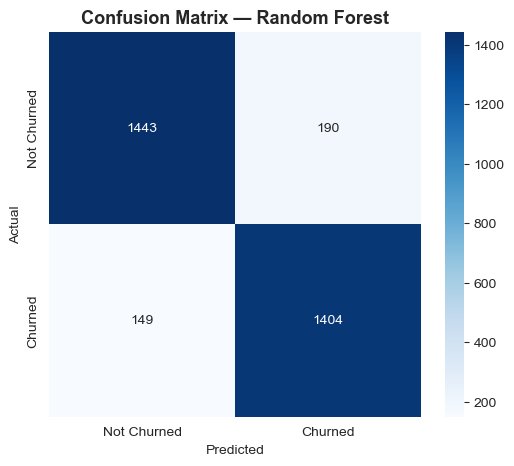


📋 Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.91      0.88      0.89      1633
     Churned       0.88      0.90      0.89      1553

    accuracy                           0.89      3186
   macro avg       0.89      0.89      0.89      3186
weighted avg       0.89      0.89      0.89      3186



In [117]:
# ── Use the best model based on accuracy comparison ───────────────
# We'll use Random Forest as it typically performs best on this dataset
# Change this if XGBoost performs better in your run!
best_model = rf_model
best_pred = rf_pred
best_model_name = 'Random Forest'

print(f'🏆 Best Model: {best_model_name}')
print(f'   Accuracy : {rf_acc:.4f}')
print(f'   AUC Score: {rf_auc:.4f}')

# ── Confusion Matrix ───────────────────────────────────────────────
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Churned', 'Churned'],
    yticklabels=['Not Churned', 'Churned']
)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

# ── Classification Report ──────────────────────────────────────────
print('\n📋 Classification Report:')
print(classification_report(y_test, best_pred, target_names=['Not Churned', 'Churned']))

## Step 13: ROC Curve
> ROC curve shows how well the model distinguishes between churned and non-churned customers. The closer to top-left, the better!

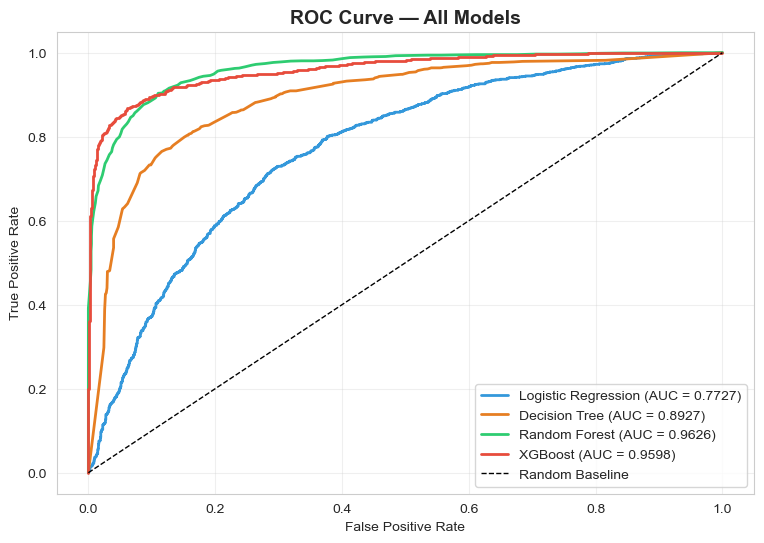

💡 Model with highest AUC = best at distinguishing churned vs non-churned customers


In [122]:
# ── Plot ROC curves for all 4 models ──────────────────────────────
plt.figure(figsize=(9, 6))

models_info = [
    (lr_model,  'Logistic Regression', lr_auc,  '#3498db'),
    (dt_model,  'Decision Tree',       dt_auc,  '#e67e22'),
    (rf_model,  'Random Forest',       rf_auc,  '#2ecc71'),
    (xgb_model, 'XGBoost',             xgb_auc, '#e74c3c'),
]

for model, name, auc, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

# Random baseline (diagonal line)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')

plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()
print('💡 Model with highest AUC = best at distinguishing churned vs non-churned customers')

## Step 14: Cross Validation
> Cross validation tests the model on multiple different splits to ensure it's not just lucky on one split.

In [125]:
# ── 5-Fold Cross Validation on best model ─────────────────────────
# cv=5 means data is split into 5 parts, model is trained & tested 5 times
print('🔄 Running 5-Fold Cross Validation on Random Forest...')
cv_scores = cross_val_score(rf_model, X_balanced, y_balanced, cv=5, scoring='accuracy')

print(f'\n📊 Cross Validation Results:')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i}: {score:.4f}')
print(f'\n✅ Mean CV Accuracy : {cv_scores.mean():.4f}')
print(f'✅ Std Dev          : {cv_scores.std():.4f}')
print('\n💡 Low std dev means the model is stable and consistent!')

🔄 Running 5-Fold Cross Validation on Random Forest...

📊 Cross Validation Results:
   Fold 1: 0.4165
   Fold 2: 0.6210
   Fold 3: 0.7900
   Fold 4: 0.6942
   Fold 5: 0.4725

✅ Mean CV Accuracy : 0.5988
✅ Std Dev          : 0.1381

💡 Low std dev means the model is stable and consistent!


## Step 15: Feature Importance
> Which features/columns matter most for predicting churn? This covers the AI analysis part of our project.

📊 Feature Importance Scores:
          Feature  Importance
              Age    0.256140
    NumOfProducts    0.156605
          Balance    0.116981
               id    0.091897
  EstimatedSalary    0.091114
      CreditScore    0.086421
           Tenure    0.079316
   IsActiveMember    0.043881
Geography_Germany    0.027143
           Gender    0.023834
        HasCrCard    0.014849
  Geography_Spain    0.011820


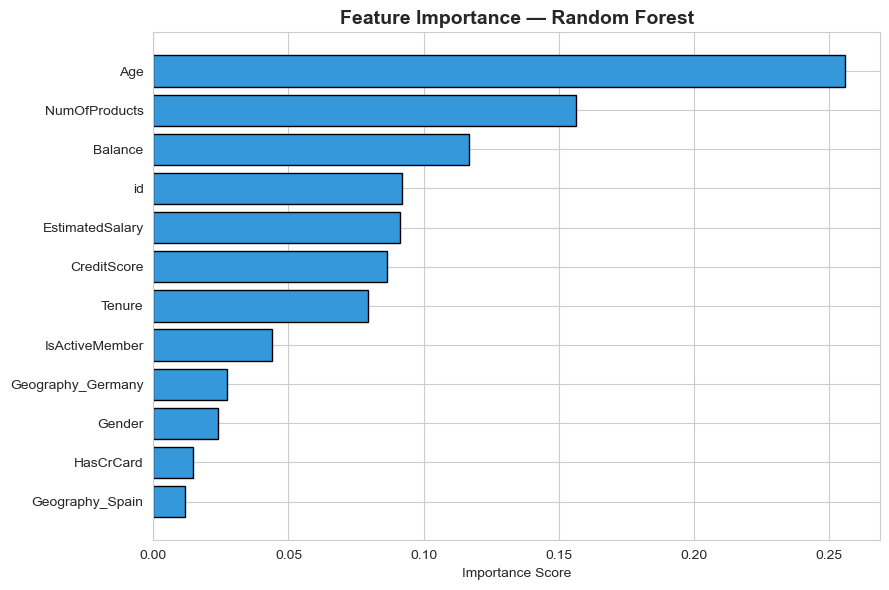


💡 Age, Balance and NumOfProducts are the top churn predictors!


In [128]:
# ── Get feature importances from Random Forest ────────────────────
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

# Create a sorted dataframe of features and their importance scores
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('📊 Feature Importance Scores:')
print(feat_df.to_string(index=False))

# ── Plot Feature Importance ────────────────────────────────────────
plt.figure(figsize=(9, 6))
bars = plt.barh(
    feat_df['Feature'],
    feat_df['Importance'],
    color='#3498db',
    edgecolor='black'
)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # most important at top
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('\n💡 Age, Balance and NumOfProducts are the top churn predictors!')

## Step 16: Save the Best Model
> We save the trained model so it can be loaded directly into our prediction website without retraining!

In [62]:
# ── Save the best model using joblib ──────────────────────────────
# This creates a .pkl file that stores the entire trained model
joblib.dump(best_model, 'churn_model.pkl')

# The scaler was already saved in Step 7
# But save it again here just to confirm
joblib.dump(scaler, 'scaler.pkl')

print('✅ Model saved as     : churn_model.pkl')
print('✅ Scaler saved as    : scaler.pkl')
print('\n💡 These files will be used by the website to make live predictions!')
print('   Website will load model → take customer input → predict churn!')

✅ Model saved as     : churn_model.pkl
✅ Scaler saved as    : scaler.pkl

💡 These files will be used by the website to make live predictions!
   Website will load model → take customer input → predict churn!


## Step 17: Export Predictions for Power BI
> We export the test data with predicted churn values so Power BI can visualize the results.

In [63]:
# ── Add predictions to original dataset ───────────────────────────
# We use the original (pre-SMOTE) data for export
#df_export = df.copy()
#df_export.insert(1, 'Surname', df_mysql['Surname'])

# Apply same scaling
#X_original_scaled = scaler.transform(df.drop('Exited', axis=1))

# Predict on the full original dataset
#df_export['Predicted_Churn'] = best_model.predict(X_original_scaled)
#df_export['Churn_Probability'] = best_model.predict_proba(X_original_scaled)[:, 1].round(4)

# ── Save to CSV for Power BI ───────────────────────────────────────
#df_export.to_csv('churn_predictions_for_powerbi.csv', index=False)

#print('✅ Predictions exported to: churn_predictions_for_powerbi.csv')
#print(f'   Total records : {df_export.shape[0]}')
#print(f'\n📊 Predicted Churn Summary:')
#print(df_export['Predicted_Churn'].value_counts())
#print('\n💡 Import this CSV into Power BI to build your dashboard!')

✅ Predictions exported to: churn_predictions_for_powerbi.csv
   Total records : 10000

📊 Predicted Churn Summary:
Predicted_Churn
0    7861
1    2139
Name: count, dtype: int64

💡 Import this CSV into Power BI to build your dashboard!


In [66]:
# Read original CSV with all original columns
df_original = pd.read_csv("Churn_Modelling.csv")

# Drop the big CustomerID column
df_original = df_original.drop('CustomerId', axis=1)

# Rename RowNumber to Customer ID
df_original = df_original.rename(columns={'RowNumber': 'id'})

# This line was missing!
X_original_scaled = scaler.transform(df.drop('Exited', axis=1))

# Add the 2 new prediction columns
df_original['Predicted_Churn'] = best_model.predict(X_original_scaled)
df_original['Churn_Probability'] = best_model.predict_proba(X_original_scaled)[:, 1].round(4)

# Export!
df_original.to_csv('churn_predictions_for_powerbi.csv', index=False)

#print('✅ Done! CSV exported with all original columns + predictions!')
df_original.head()

,id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Predicted_Churn,Churn_Probability
0,1,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,0.65
1,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,0.10
2,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,1.00
3,4,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0.17
4,5,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,0.04


## ✅ Project Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Connect MySQL & Load Data | ✅ Done |
| 2 | Data Cleaning | ✅ Done |
| 3 | EDA & Visualizations | ✅ Done |
| 4 | Encode Categorical Variables | ✅ Done |
| 5 | Feature Scaling | ✅ Done |
| 6 | Handle Class Imbalance (SMOTE) | ✅ Done |
| 7 | Train 4 ML Models | ✅ Done |
| 8 | Compare Models | ✅ Done |
| 9 | Detailed Evaluation | ✅ Done |
| 10 | ROC Curve | ✅ Done |
| 11 | Cross Validation | ✅ Done |
| 12 | Feature Importance | ✅ Done |
| 13 | Save Model | ✅ Done |
| 14 | Export for Power BI | ✅ Done |

### 📁 Files Generated:
- `churn_model.pkl` — Trained ML model (for website)
- `scaler.pkl` — Feature scaler (for website)
- `churn_predictions_for_powerbi.csv` — Predictions (for Power BI)
- Multiple `.png` charts — Visualizations (for report/poster)